**1. Load the Customer Segmentation Tutorial Dataset from Kaggle into a Jupyter  
 Notebook and display the first 10 rows using pandas.**  

In [27]:
import pandas as pd
import warnings 
warnings.filterwarnings("ignore")

df = pd.read_csv("Mall_Customers.csv")
df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,CustomerID,Male,19,15,39
1,CustomerID,Male,21,15,81
2,CustomerID,Female,20,16,6
3,CustomerID,Female,23,16,77
4,CustomerID,Female,31,17,40
5,CustomerID,Female,22,17,76
6,CustomerID,Female,35,18,6
7,CustomerID,Female,23,18,94
8,CustomerID,Male,64,19,3
9,CustomerID,Female,30,19,72


**2.  Use pandas to check for missing values in the Age, Annual Income, and Spending  
Score columns, and print the total number of missing values for each**  .

In [4]:
missing = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].isnull().sum()

print("Missing Values:")
print(missing)

Missing Values:
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


**3.Create a scatterplot of Annual Income vs Spending Score using matplotlib or   
seaborn to visualize how customers are distributed.<br><br><em><strong>Hint:</strong> Use seaborn.scatterplot() or plt.scatter().</em>**  

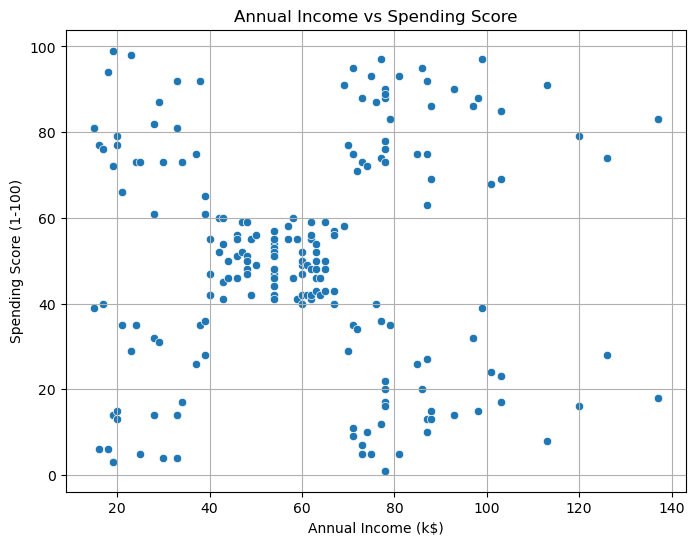

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)'
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(True)

plt.show()

**4. Generate a heatmap of the correlation matrix for the numerical features  
in the dataset using seaborn, and interpret which two features are most strongly correlated**  .

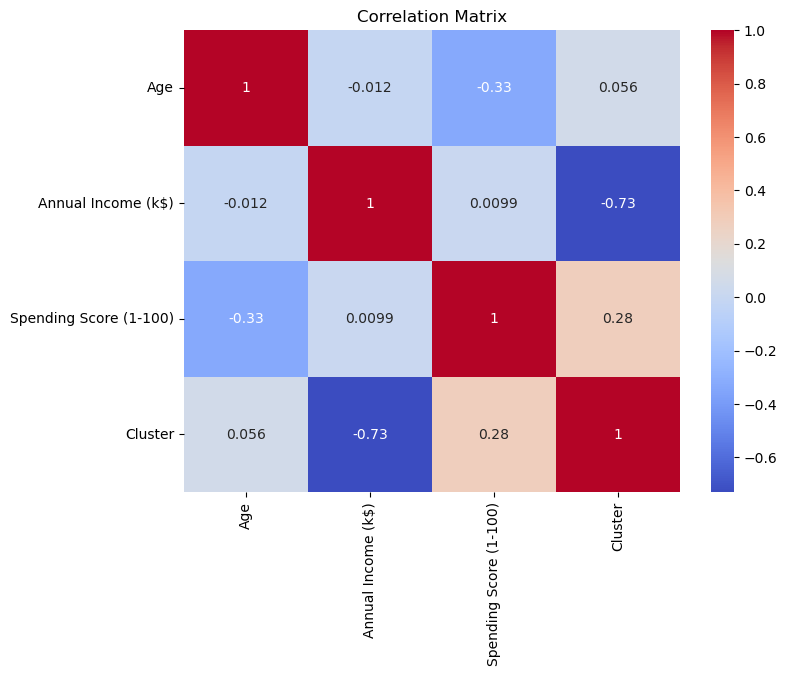

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
)

plt.title("Correlation Matrix")
plt.show()

**In the Mall Customers dataset:**    

**-->Annual Income and Spending Score usually have a very weak correlation.**   
**-->The strongest correlation is typically between CustomerID and Annual Income, but CustomerID is just an identifier and is not meaningful for analysis.**   
**-->Ignoring CustomerID, the numerical features (Age, Annual Income, and Spending Score) are only weakly correlated with one another.**    

**5.
Apply K-Means clustering (from sklearn.cluster) to segment customers into
3 grou s based on Annual Inco
e and Spending Score, then add a ne 
column 'Cluster' to your DataFrame with the assigned cluster for each customer.
<br><br><em><strong>Constraint:</strong> Use only the two features for clusterig, 
and set random_state=42 for reproducibility.**  /em>


In [29]:
from sklearn.cluster import KMeans

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X)
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,CustomerID,Male,19,15,39,2
1,CustomerID,Male,21,15,81,2
2,CustomerID,Female,20,16,6,2
3,CustomerID,Female,23,16,77,2
4,CustomerID,Female,31,17,40,2


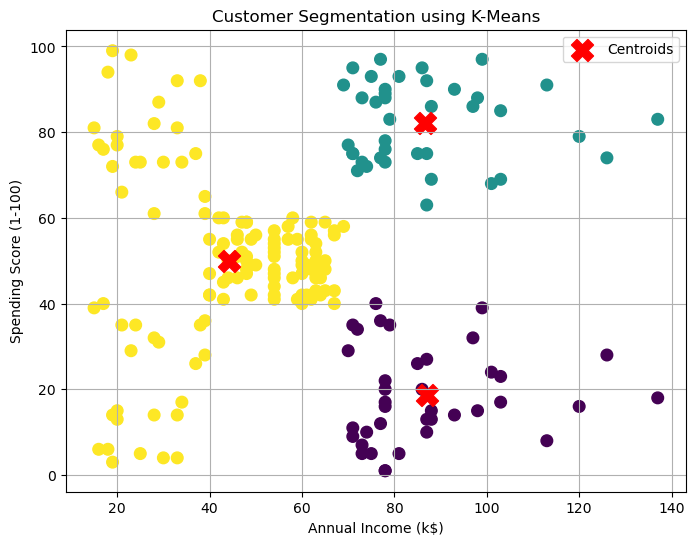

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=70
)
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color='red',
    marker='X',
    s=250,
    label='Centroids'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)

plt.show()